# Phase 3: Modelling and Evaluation

The modelling process begins by loading the cleaned, feature engineered dataset (`data/processed/cleaned_features.csv`). Decoupling this phase from the data cleaning logic ensures the pipeline remains modular, allowing adjustments to cleaning steps to flow downstream without forcing a complete rewrite.

The modelling workflow follows this sequence:
1. Splitting the data using stratification to preserve the severe class balance across both training and testing sets.
2. Establishing a baseline using a simple logistic regression model to set a performance floor.
3. Training an advanced ensemble model using scikit-learn's `HistGradientBoostingClassifier`, which delivers robust gradient boosting capabilities without requiring external package installations.
4. Evaluating performance exclusively using ROC-AUC and Precision-Recall AUC (PR-AUC), bypassing standard accuracy entirely due to the class imbalance.
5. Serializing the winning model to disk for downstream use in Phase 4 explainability and Phase 6 dashboard deployment.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('../data/processed/cleaned_features.csv', index_col=0)
print(df.shape)


(149999, 17)


## Splitting the Data and Verifying Class Balance

The dataset is partitioned into feature matrices (`X`) and the target variable (`y`). Using `stratify=y` within the `train_test_split` function ensures that the natural 93 to 7 class distribution is strictly maintained across both the training and testing sets. Setting `random_state=42` guarantees full reproducibility across future executions. 

The resulting split is verified immediately after partitioning to confirm that the default ratio matches the overall population distribution.

In [9]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain balance:\n", y_train.value_counts(normalize=True))
print("\nTest balance:\n", y_test.value_counts(normalize=True))


Train shape: (119999, 16) Test shape: (30000, 16)

Train balance:
 SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64

Test balance:
 SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


## Baseline Model: Logistic Regression

The modelling phase starts with a standard logistic regression to establish an empirical performance floor. Two core preprocessing steps are required:

- **`StandardScaler`**: Normalizes all features to a standard scale. Because logistic regression calculates coefficients based on magnitude, having features ranging from age (tens) to income (thousands) would otherwise skew the optimisation. Tree-based models handled later do not require this step.
- **`class_weight='balanced'`**: Adjusts loss penalties to account for the severe class imbalance (~93% non-default vs. ~7% default). Without this adjustment, the model would default to predicting the majority class to artificially inflate standard accuracy metrics.

In [10]:
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)

log_reg_probs = log_reg_pipeline.predict_proba(X_test)[:, 1]
log_reg_auc = roc_auc_score(y_test, log_reg_probs)
log_reg_pr_auc = average_precision_score(y_test, log_reg_probs)

print(f"Logistic Regression - ROC-AUC: {log_reg_auc:.3f}, PR-AUC: {log_reg_pr_auc:.3f}")


Logistic Regression - ROC-AUC: 0.861, PR-AUC: 0.382


## Evaluating Real-World Trade-Offs at a Fixed Threshold

A single ROC-AUC score masks the practical reality of deploying a model into production. Examining the classification report and confusion matrix at the default 0.5 threshold reveals the actual operational trade-off: the exact number of genuine defaulters captured versus the number of creditworthy borrowers wrongly flagged. This operational balance forms the core of any risk discussion with business stakeholders.

In [11]:
y_pred_lr = log_reg_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.74      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.62     30000
weighted avg       0.93      0.81      0.85     30000

Confusion matrix:
 [[22787  5208]
 [  513  1492]]


## A Stronger Model: Gradient Boosted Trees

While logistic regression assumes linear relationships between features and risk, gradient boosted trees automatically capture complex interactions—such as high utilisation being particularly dangerous only when income is low—without requiring manual feature engineering. Furthermore, tree-based models are invariant to monotonic feature transformations, meaning they do not require standard scaling.


In [12]:
hgb_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
hgb_model.fit(X_train, y_train)

hgb_probs = hgb_model.predict_proba(X_test)[:, 1]
hgb_auc = roc_auc_score(y_test, hgb_probs)
hgb_pr_auc = average_precision_score(y_test, hgb_probs)

print(f"Gradient Boosting - ROC-AUC: {hgb_auc:.3f}, PR-AUC: {hgb_pr_auc:.3f}")
print(f"(Logistic Regression was - ROC-AUC: {log_reg_auc:.3f}, PR-AUC: {log_reg_pr_auc:.3f})")


Gradient Boosting - ROC-AUC: 0.869, PR-AUC: 0.403
(Logistic Regression was - ROC-AUC: 0.861, PR-AUC: 0.382)


## Side-by-Side Curve Comparison

Comparing the Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves side by side highlights why PR-AUC is the definitive metric for this task. While ROC-AUC can appear inflated on severely imbalanced datasets due to the vast majority of easy-to-predict true negatives, the precision-recall curve focuses entirely on the minority default class. This reveals true performance where the problem is actually difficult, directly matching the risk profile required for the dashboard view.

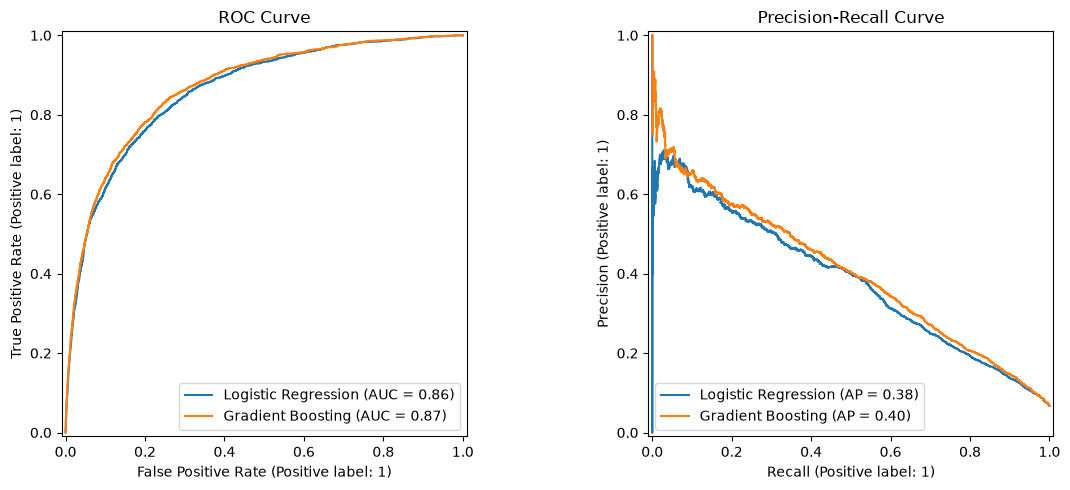

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, log_reg_probs, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, hgb_probs, name="Gradient Boosting", ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, log_reg_probs, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, hgb_probs, name="Gradient Boosting", ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig('../data/processed/model_comparison_curves.png', dpi=150)
plt.show()


## Saving the Winning Model Based on Empirical Evidence

The model selection is driven strictly by quantitative performance on the held-out test set, specifically prioritizing the highest Precision-Recall AUC (PR-AUC) rather than arbitrarily choosing the final model trained. The winning model is serialized and saved to disk, ensuring that Phase 4 (explainability) and Phase 6 (dashboard deployment) consume the exact same artifact without requiring retraining.


In [14]:
if hgb_pr_auc >= log_reg_pr_auc:
    final_model = hgb_model
    final_name = "HistGradientBoostingClassifier"
else:
    final_model = log_reg_pipeline
    final_name = "LogisticRegression pipeline"

joblib.dump(final_model, '../data/processed/credit_risk_model.joblib')
print(f"Saved final model: {final_name}")


Saved final model: HistGradientBoostingClassifier


## Notebook Completion and Summary

Notebook 3 establishes a reproducible modelling pipeline. Beginning with a stratified split that preserves the underlying class imbalance, the workflow builds and evaluates both a baseline logistic regression and an advanced gradient boosted trees classifier. By prioritizing Precision-Recall AUC over standard accuracy and ROC-AUC, the evaluation accurately reflects performance on the minority default class. 

The superior model is selected based on empirical evidence and serialized to disk, establishing a reliable artifact ready to feed into Phase 4 (explainability) and Phase 6 (dashboard deployment).